# Modelo Predicción Desempeño Estudiantes High School
Integrantes
- Maria Paulina Salazar
- Oscar Lotero

En este link de Github se escuentra todo el proyecto relacionado al taller:
https://github.com/OscarLG10/taller_3_mlops

## 1. Entedimiento del Negocio
- **Objetivo de negocio**: En una institución de educación escolar (High School) se quiere anticipar el desempeño académico de los estudiantes a partir de un conjunto de variables para poder brindar una atención temprana a aquellos estudiantes que se consideren en riesgo de tener un bajo desempeño académico.

- **Objetivo analítico**: Construir experimentos para evaluar y escoger un modelo de ML que permita clasificar los estudiante en una categoría de desempeño académico a partir de las variables proporcionadas de cada estudiante.

## 2. Exploración de datos
Objetivo: Entender el estado de calidad de los datos
- Identificación de datos nulos
- Análisis univariado (desbalance en categóricas y sesgo en numéricas)
- Análisis bivariado (multicolinealidad)

In [21]:
# Cargar datos
import pandas as pd
df_raw = pd.read_csv('data/Student_performance_data _.csv')


In [22]:
# Identificación de datos nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [23]:
# Ajuste de tipo de dato y elminación de columnas no relevantes
df = df_raw.drop(columns=['StudentID', 'GPA'])

categorical_features = [
    'Age','Gender', 'Ethnicity', 'ParentalEducation', 
    'Tutoring', 'ParentalSupport', 'Extracurricular', 
    'Sports', 'Music', 'Volunteering', 'GradeClass'
    ]

for c in df.columns:
    if c in categorical_features:
        df[c] = df[c].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                2392 non-null   category
 1   Gender             2392 non-null   category
 2   Ethnicity          2392 non-null   category
 3   ParentalEducation  2392 non-null   category
 4   StudyTimeWeekly    2392 non-null   float64 
 5   Absences           2392 non-null   int64   
 6   Tutoring           2392 non-null   category
 7   ParentalSupport    2392 non-null   category
 8   Extracurricular    2392 non-null   category
 9   Sports             2392 non-null   category
 10  Music              2392 non-null   category
 11  Volunteering       2392 non-null   category
 12  GradeClass         2392 non-null   category
dtypes: category(11), float64(1), int64(1)
memory usage: 63.5 KB


In [24]:
# Analisis descriptivo
df.describe(exclude=['category'])



,StudyTimeWeekly,Absences
count,2392.000000,2392.000000
mean,9.771992,14.541388
std,5.652774,8.467417
min,0.001057,0.000000
25%,5.043079,7.000000
50%,9.705363,15.000000
75%,14.408410,22.000000
max,19.978094,29.000000


In [25]:
df.describe(include=['category'])


,Age,Gender,Ethnicity,ParentalEducation,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
count,2392,2392,2392,2392,2392,2392,2392,2392,2392,2392,2392.0
unique,4,2,4,5,2,5,2,2,2,2,5.0
top,15,1,0,2,0,2,0,0,0,0,4.0
freq,630,1222,1207,934,1671,740,1475,1666,1921,2016,1211.0


### Análisis univariado

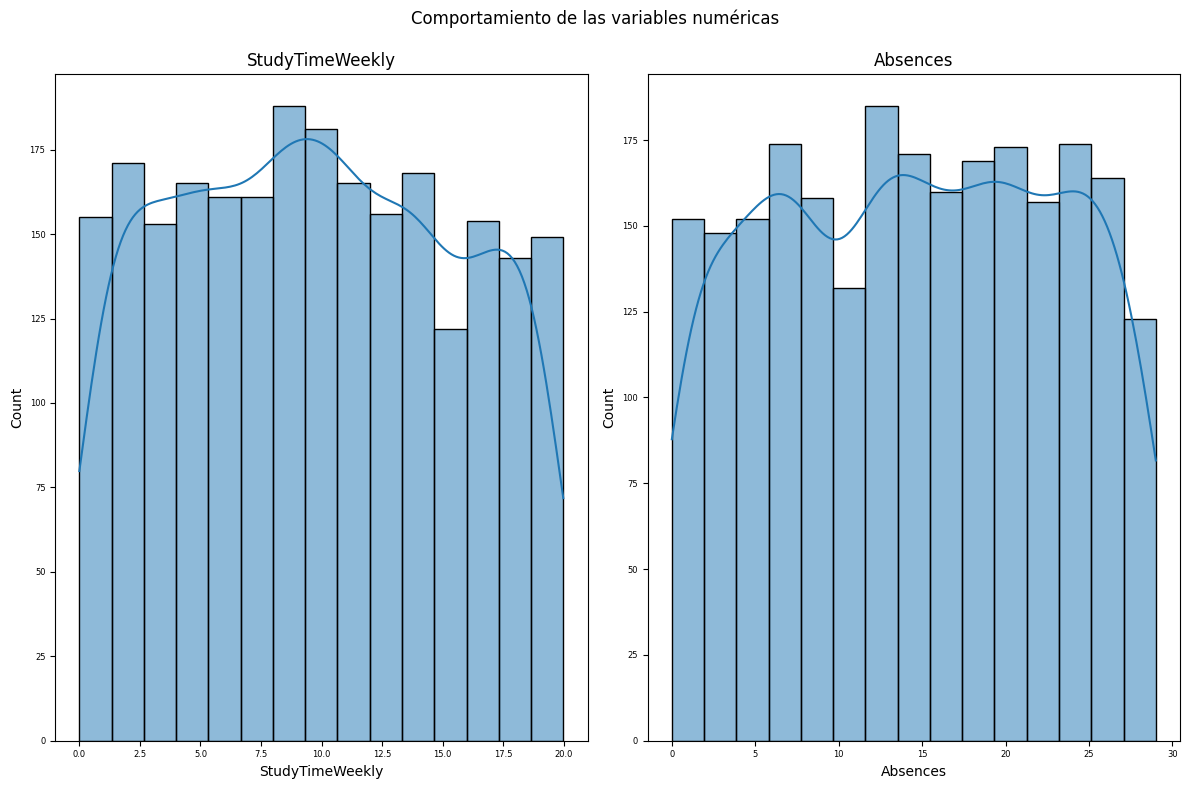

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize = (12, 8))
ax = ax.flat
num_col = df.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = df, x = col, kde = True, ax = ax[i], bins = 15)
    ax[i].set_title(col)
    ax[i].tick_params(labelsize = 6)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de las variables numéricas')
plt.show()

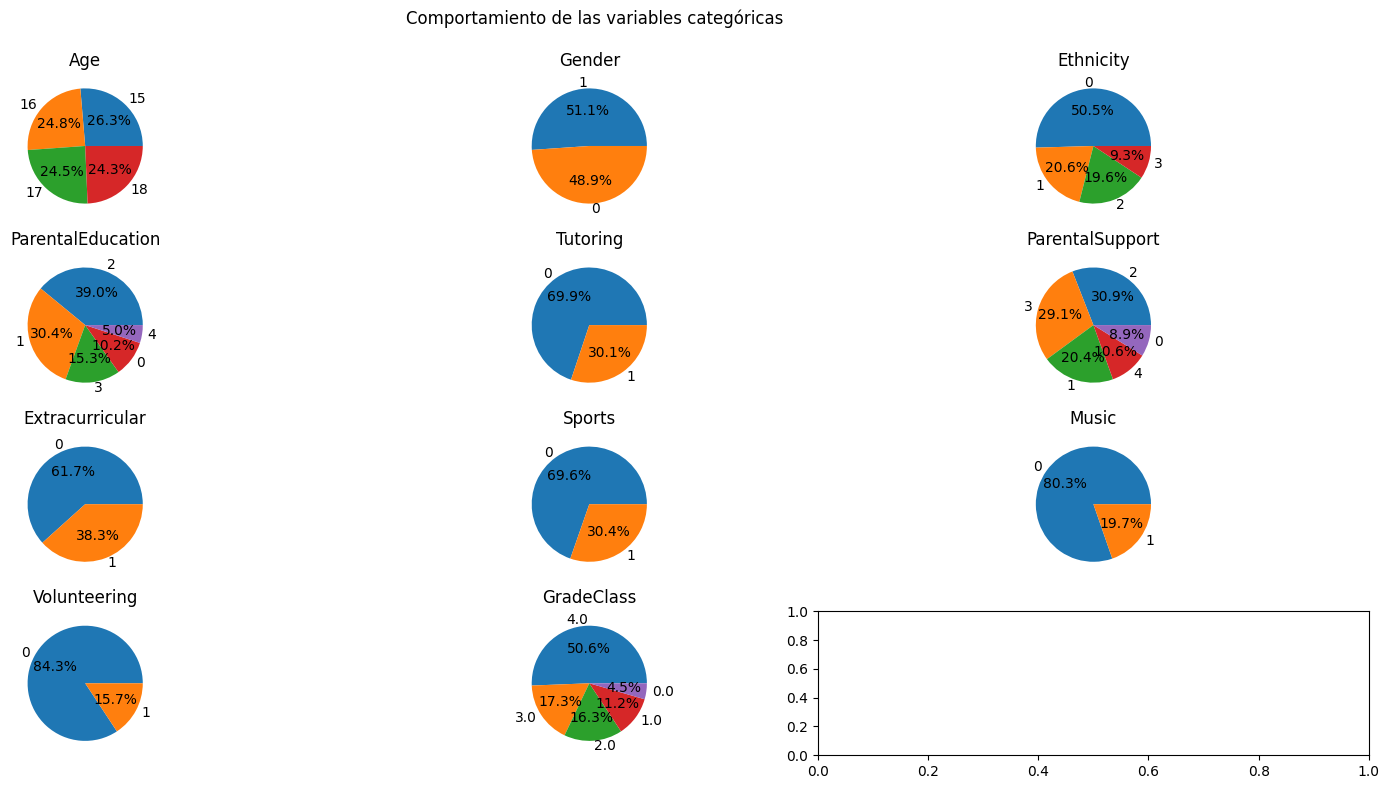

In [27]:
fig, ax = plt.subplots(4, 3, figsize = (16, 8))
ax = ax.flat
cat_col = categorical_features
for i, col in enumerate(cat_col):
    ax[i].pie(x = df[col].value_counts(),
              labels = df[col].value_counts().index,
              autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de las variables categóricas')
plt.show()

1. Si bien el 50% del dataset pertenece a la clase 4 del target, no hay desbalance muy grande el resto de clase.
2. Algunas featuares categoricas como Volunteering presenta un desbalance grande, puede contener algunos individuos que puedan ayudar en la identificaciones para la predicción. Se decide dejar todas las feature categoricas en el dataset ya que no hay ninguna con alguna clase que representa mas del 90%.

### Análisis bivariado
Crosstab normalizado por fila: proporción de `GradeClass` dentro de cada categoría.

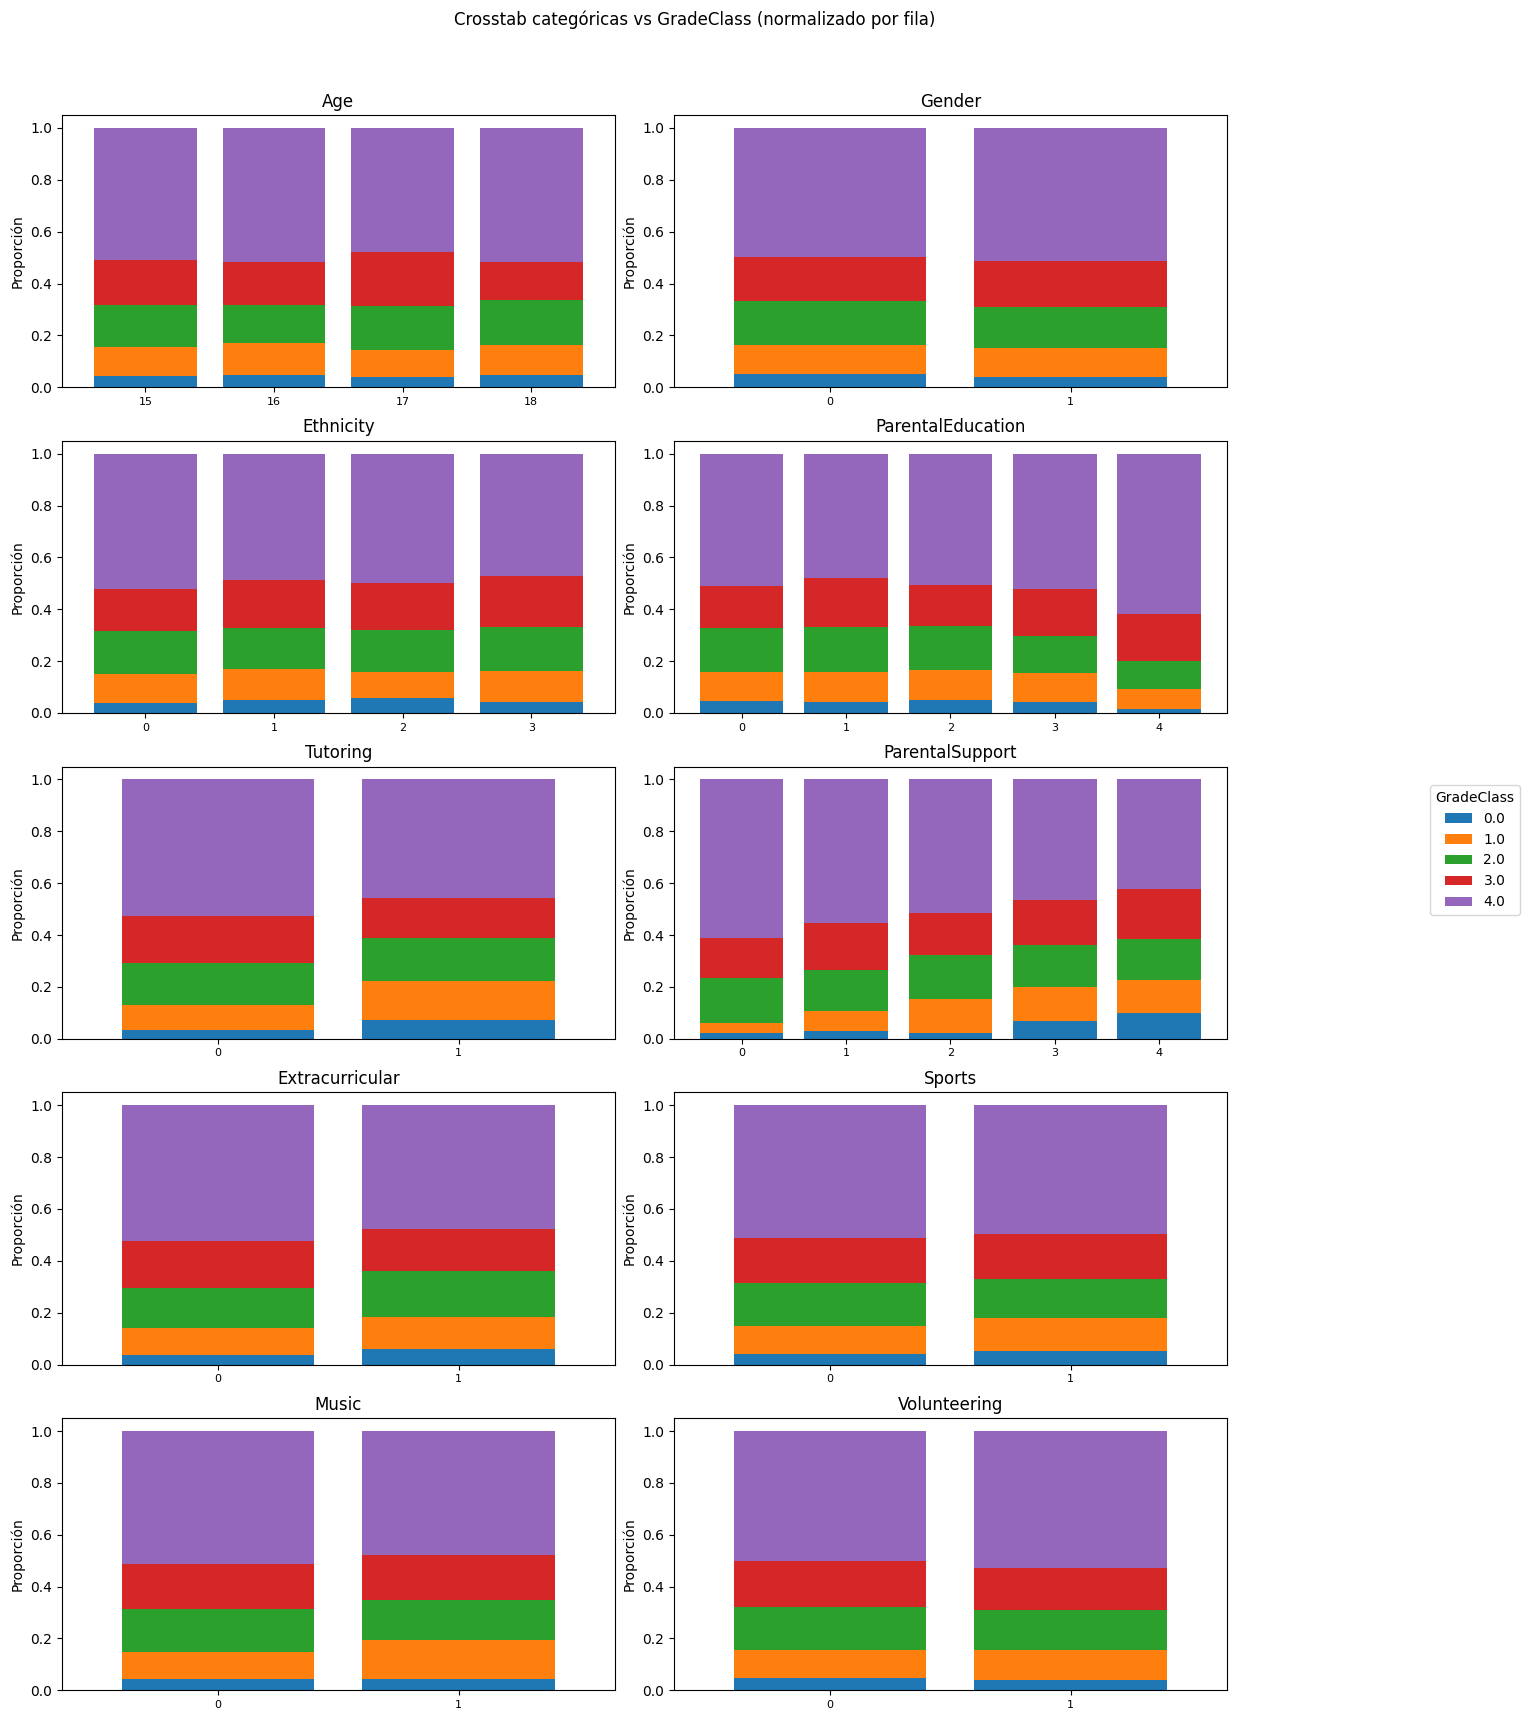

In [28]:
target = 'GradeClass'
predictors = [c for c in categorical_features if c != target]

n_cols = 2
n_rows = (len(predictors) + n_cols - 1) // n_cols
fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
ax = ax.flat

for i, col in enumerate(predictors):
    ct = pd.crosstab(df[col], df[target], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax[i], legend=(i == 0), width=0.8)
    ax[i].set_title(col)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Proporción')
    ax[i].tick_params(axis='x', rotation=0, labelsize=8)

for j in range(len(predictors), len(ax)):
    ax[j].set_visible(False)

if ax[0].get_legend() is not None:
    ax[0].get_legend().remove()


handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title=target, bbox_to_anchor=(1.02, 0.5), loc='center left')

fig.tight_layout()
fig.subplots_adjust(top=0.92, right=0.88)
fig.suptitle('Crosstab categóricas vs GradeClass (normalizado por fila)')
plt.show()

A partir de este analisis crosstab, se decide eliminar los festures "Volunteering" y "Music" ya que son los features mas desbalanceados y su distribución no cambia practicamente nada respecto al GradeClass (Target)

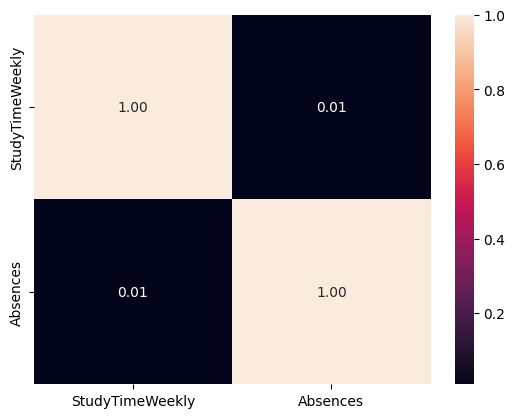

In [29]:
sns.heatmap(data = df.corr(numeric_only = True), annot = True,
            fmt = '0.2f')
plt.show()

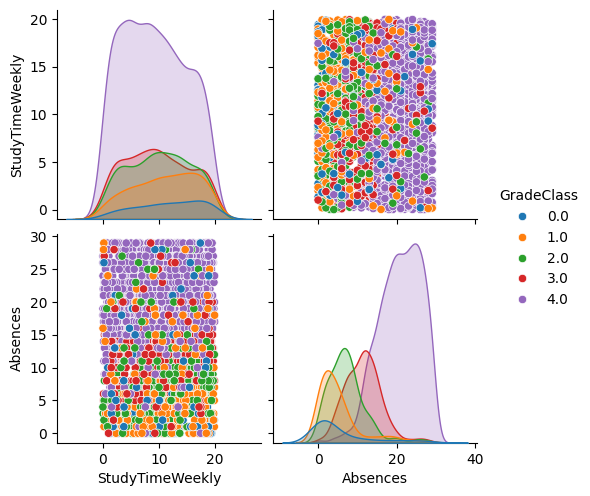

In [30]:
sns.pairplot(data = df, hue = 'GradeClass', kind = 'scatter')
plt.show()

- No se encuentra una correlación grande entre variable numericas 
- Se ve una acumulación interezante en la distribución de las de ausencias en la categoria 4 del target (La de peor desempeño). Esta categoria es la que tiene mayor acumulacion de individuos con mas ausencias durante el año escolar. Este es un comportamiento esperable en al realidad.

In [31]:
# Dataset curado
df_curado = df.drop(columns=['Volunteering', 'Music'])
df_curado.info()



<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                2392 non-null   category
 1   Gender             2392 non-null   category
 2   Ethnicity          2392 non-null   category
 3   ParentalEducation  2392 non-null   category
 4   StudyTimeWeekly    2392 non-null   float64 
 5   Absences           2392 non-null   int64   
 6   Tutoring           2392 non-null   category
 7   ParentalSupport    2392 non-null   category
 8   Extracurricular    2392 non-null   category
 9   Sports             2392 non-null   category
 10  GradeClass         2392 non-null   category
dtypes: category(9), float64(1), int64(1)
memory usage: 58.9 KB


## 3. Preparación de datos
Pipeline de preprocesamiento con `ColumnTransformer`:
- **Numéricas** (`StudyTimeWeekly`, `Absences`): `StandardScaler`
- **Categóricas** (predictores): `OneHotEncoder`

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

target = 'GradeClass'
numeric_features = ['StudyTimeWeekly', 'Absences']
categorical_predictors = [
    c for c in df_curado.select_dtypes(include=['category']).columns 
    if c != target
    ]

X = df_curado.drop(columns=[target]).copy()
y = df_curado[target].astype(int)

# Enteros simples: evitan errores de pickle con joblib en validación cruzada paralela
for col in categorical_predictors:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_predictors),
    ]
)

def build_pipeline(classifier):
    """Arma el pipeline completo: preprocesamiento + modelo."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier),
    ])

preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_train_transformed = preprocessing_pipeline.fit_transform(X_train)
print(f'Features originales: {X_train.shape[1]}')
print(f'Features transformadas: {X_train_transformed.shape[1]}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Features originales: 10
Features transformadas: 28
Train: 1913 | Test: 479


* Investigue y defina un listado de las transformaciones o procesos más usados en
esta etapa.

---

1. Transformación de Variables Numéricas
Los modelos basados en distancias (como *KNN* o *SVM*) o en optimización por gradiente descendente (como la *Regresión Logística* y las *Redes Neuronales*) son altamente sensibles a la escala de las características.

* **Normalización (*Min-Max Scaling*):**
  Transforma los datos para que todos los valores se ubiquen en un rango estricto, típicamente entre 0 y 1. Es ideal cuando los datos no siguen una distribución normal y no se quiere asumir ninguna distribución a priori.
  
  $$x_{new} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

* **Estandarización (*Z-score Scaling*):**
  Centra los datos restando la media y dividiendo por la desviación estándar, resultando en una distribución con $\mu = 0$ y $\sigma = 1$. Es indispensable para algoritmos como **PCA** (*Análisis de Componentes Principales*) o **Support Vector Machines**.
  
  $$x_{new} = \frac{x - \mu}{\sigma}$$

* **Transformaciones de Estabilización de Varianza (Logarítmica, Box-Cox, Yeo-Johnson):**
  Se aplican a variables con un alto sesgo positivo (asimetría a la derecha). Al aplicar un logaritmo o una transformación de potencia, se comprime la dispersión de los valores extremos y se aproxima la variable a una distribución normal (gaussiana), mejorando el rendimiento de los modelos lineales.

---

2. Codificación de Variables Categóricas (*Categorical Encoding*)
Los algoritmos de Machine Learning operan estrictamente en el dominio numérico. Las variables de texto o categorías deben ser mapeadas a vectores matemáticos.

* **One-Hot Encoding:**
  Crea una nueva columna binaria (0 o 1) por cada categoría única en la variable original. Se utiliza para **variables nominales** (donde no existe un orden intrínseco, ej. *País, Color*). *Nota: Puede generar problemas de alta dimensionalidad si la cardinalidad es muy alta.*
* **Ordinal Encoding o Label Encoding:**
  Asigna un número entero consecutivo a cada categoría ($0, 1, 2, \dots$). Se debe utilizar **únicamente si existe un orden jerárquico implícito** en los datos.
* **Target Encoding (Codificación por la Variable Objetivo):**
  Reemplaza cada categoría con la media de la variable objetivo (*target*) para esa categoría específica. Muy efectivo en variables con alta cardinalidad, aunque requiere técnicas de regularización (como el suavizado) para mitigar el riesgo de sobreajuste (*overfitting*).

---

3. Ingeniería de Características (*Feature Engineering*)
Este proceso combina el conocimiento del dominio de negocio con la matemática para extraer o construir nuevas variables explicativas que faciliten el aprendizaje del modelo.

* **Características Polinomiales y de Interacción:**
  Crear combinaciones multiplicativas o potencias de variables existentes (ej. $x_1 \cdot x_2$ o $x_1^2$) para permitir que modelos lineales capturen relaciones e interacciones no lineales complejas.
* **Descomposición de Componentes de Tiempo (*Datetime Decomposition*):**
  Extraer variables numéricas específicas a partir de una marca de tiempo (`YYYY-MM-DD`). Por ejemplo: *Año, Mes, Día del mes, Día de la semana (0-6), Hora del día, o variables booleanas como `is_weekend`*.
* **Agrupamiento (*Binning* / Discretización):**
  Transformar variables continuas en intervalos discretos (categorías numéricas). Por ejemplo, convertir la "Edad" en rangos generacionales o grupos de riesgo.

---

4. Reducción de Dimensionalidad y Selección de Características
Cuando trabajamos con demasiadas variables independientes, corremos el riesgo de sufrir la *"maldición de la dimensionalidad"*, lo que incrementa el costo computacional y degrada la capacidad de generalización del modelo.

* **PCA (*Principal Component Factor* / Análisis de Componentes Principales):**
  Técnica de aprendizaje no supervisado que proyecta las características originales en un nuevo espacio ortogonal de menor dimensión. Los nuevos ejes (componentes principales) son combinaciones lineales de las variables originales y se ordenan por la cantidad de varianza matemática que retienen.
* **Selección de Características (*Feature Selection*):**
  * *Métodos de Filtro (Filter Methods):* Evaluación estadística de la relación individual de cada variable con el target (ej. *Correlación de Pearson, ANOVA, Chi-cuadrado*).
  * *Métodos Embebidos (Embedded Methods):* Algoritmos que seleccionan variables intrínsecamente durante su entrenamiento, como la regularización L1 (Lasso) o los scores de importancia de características basados en árboles de decisión (*Random Forest, XGBoost*).

---

5. Manejo de Desbalanceo de Clases (*Class Imbalance*)
Común en problemas de clasificación donde la variable objetivo tiene una distribución severamente asimétrica (ej. *Detección de fraudes financieros, fallas de maquinaria, o diagnósticos médicos*).

* **Submuestreo (*Undersampling*):** Reducir de manera aleatoria o estratégica el número de muestras de la clase mayoritaria.
* **Sobremuestreo (*Oversampling* / SMOTE):** Generar sintéticamente nuevos ejemplos de la clase minoritaria utilizando técnicas como **SMOTE** (*Synthetic Minority Over-sampling Technique*), la cual crea vectores intermedios basados en los vecinos más cercanos de los datos minoritarios reales, evitando que el modelo se sesgue hacia la clase predominante.

## 4. Modelación
- **6 modelos**: Regresión Logística, KNN, SVM, Árbol de Decisión, **Random Forest** (ensamble), **XGBoost** (ensamble).
- **Optuna**: búsqueda de hiperparámetros por modelo (maximiza **F1 macro** en validación cruzada).
- **MLflow**: tracking de parámetros, métricas y artefactos (pipeline completo) en `sqlite:///mlflow.db`.

Para ver el dashboard local: `mlflow ui --backend-store-uri sqlite:///mlflow.db`

In [34]:
import warnings
import optuna
import mlflow
import mlflow.sklearn

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

MLFLOW_TRACKING_URI = 'sqlite:///mlflow.db'
EXPERIMENT_NAME = 'student_performance_gradeclass'
N_TRIALS = 20
CV_FOLDS = 5

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)


def create_classifier(model_name, params):
    if model_name == 'logistic_regression':
        return LogisticRegression(max_iter=2000, **params)
    if model_name == 'knn':
        return KNeighborsClassifier(**params)
    if model_name == 'svc':
        return SVC(**params)
    if model_name == 'decision_tree':
        return DecisionTreeClassifier(random_state=42, **params)
    if model_name == 'random_forest':
        return RandomForestClassifier(random_state=42, **params)
    if model_name == 'xgboost':
        return XGBClassifier(
            objective='multi:softmax',
            num_class=y.nunique(),
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0,
            **params,
        )
    raise ValueError(f'Modelo no soportado: {model_name}')


def suggest_params(model_name, trial):
    if model_name == 'logistic_regression':
        return {
            'C': trial.suggest_float('C', 1e-3, 10, log=True),
            'solver': 'lbfgs',
        }
    if model_name == 'knn':
        return {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'p': trial.suggest_int('p', 1, 2),
        }
    if model_name == 'svc':
        return {
            'C': trial.suggest_float('C', 1e-2, 10, log=True),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
        }
    if model_name == 'decision_tree':
        return {
            'max_depth': trial.suggest_int('max_depth', 3, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'random_forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }
    if model_name == 'xgboost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }
    raise ValueError(f'Modelo no soportado: {model_name}')


def make_objective(model_name):
    def objective(trial):
        params = suggest_params(model_name, trial)
        pipeline = build_pipeline(create_classifier(model_name, params))
        scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv, scoring='f1_macro', n_jobs=1
        )
        return scores.mean()
    return objective


def run_optuna_experiment(model_name, n_trials=N_TRIALS):
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param('model_name', model_name)
        mlflow.log_param('n_trials', n_trials)
        mlflow.log_param('cv_folds', CV_FOLDS)
        mlflow.log_param('optuna_scoring', 'f1_macro')

        study = optuna.create_study(
            direction='maximize',
            study_name=model_name,
            sampler=optuna.samplers.TPESampler(seed=42),
        )
        study.optimize(make_objective(model_name), n_trials=n_trials, show_progress_bar=True)

        for param, value in study.best_params.items():
            mlflow.log_param(param, value)

        mlflow.log_metric('cv_f1_macro_best', study.best_value)

        best_pipeline = build_pipeline(create_classifier(model_name, study.best_params))
        best_pipeline.fit(X_train, y_train)

        y_pred = best_pipeline.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)
        test_precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
        test_recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
        test_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

        mlflow.log_metric('test_accuracy', test_accuracy)
        mlflow.log_metric('test_precision_macro', test_precision_macro)
        mlflow.log_metric('test_recall_macro', test_recall_macro)
        mlflow.log_metric('test_f1_macro', test_f1_macro)
        mlflow.sklearn.log_model(best_pipeline, artifact_path='model')

        return {
            'model': model_name,
            'cv_f1_macro': study.best_value,
            'test_accuracy': test_accuracy,
            'test_precision_macro': test_precision_macro,
            'test_recall_macro': test_recall_macro,
            'test_f1_macro': test_f1_macro,
            'best_params': study.best_params,
            'pipeline': best_pipeline,
            'mlflow_run_id': mlflow.active_run().info.run_id,
        }


MODEL_NAMES = [
    'logistic_regression',
    'knn',
    'svc',
    'decision_tree',
    'random_forest',  # ensamble
    'xgboost',        # ensamble
]

experiment_results = [run_optuna_experiment(name) for name in MODEL_NAMES]
results_df = pd.DataFrame(experiment_results).drop(columns=['pipeline', 'best_params'])
results_df = results_df.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
metric_cols = [
    'cv_f1_macro', 'test_accuracy',
    'test_precision_macro', 'test_recall_macro', 'test_f1_macro',
]
results_df[metric_cols] = results_df[metric_cols].round(4)
results_df

Best trial: 1. Best value: 0.497858: 100%|██████████| 20/20 [00:01<00:00, 12.44it/s]
2026/06/07 13:24:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 13:24:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Best trial: 13. Best value: 0.430296: 100%|██████████| 20/20 [00:01<00:00, 17.83it/s]
2026/06/07 13:25:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 13:25:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which ca

,model,cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,mlflow_run_id
0,xgboost,0.5663,0.6848,0.5936,0.5307,0.5418,73bc0aff23f342688cb285aa27c6df19
1,svc,0.5518,0.6889,0.5445,0.5268,0.5318,45975155fc1a4d31a9f4ed1477a6089d
2,decision_tree,0.5481,0.6889,0.5325,0.5177,0.5222,9f77d0dedcdb4a51b56d4f32d1fc0380
3,logistic_regression,0.4979,0.6994,0.5421,0.5071,0.5158,b324a360e1d24a208580173614a1ce51
4,random_forest,0.4822,0.6910,0.6086,0.4943,0.5032,0e51ffa66506468d84faeb796c622714
5,knn,0.4303,0.6221,0.4374,0.4363,0.4342,1bb8afd11500401eac772e445e943812


In [35]:
# Mejor modelo según test_f1_macro
best_row = results_df.iloc[0]
best_model = next(r for r in experiment_results if r['model'] == best_row['model'])
print(f"Mejor modelo: {best_row['model']}")
print(f"CV F1 macro: {best_row['cv_f1_macro']:.4f}")
print(f"Test accuracy: {best_row['test_accuracy']:.4f}")
print(f"Test precision macro: {best_row['test_precision_macro']:.4f}")
print(f"Test recall macro: {best_row['test_recall_macro']:.4f}")
print(f"Test F1 macro: {best_row['test_f1_macro']:.4f}")
print(f"MLflow run id: {best_row['mlflow_run_id']}")
print('Hiperparámetros:', best_model['best_params'])

Mejor modelo: xgboost
CV F1 macro: 0.5663
Test accuracy: 0.6848
Test precision macro: 0.5936
Test recall macro: 0.5307
Test F1 macro: 0.5418
MLflow run id: 73bc0aff23f342688cb285aa27c6df19
Hiperparámetros: {'n_estimators': 135, 'max_depth': 3, 'learning_rate': 0.10908534722750755, 'subsample': 0.9045389085798277, 'colsample_bytree': 0.8911431246960645}


### Importancia de variables — XGBoost
Análisis de `feature_importances_` del mejor pipeline XGBoost. Las categóricas codificadas con One-Hot se agregan por variable original para facilitar la interpretación.

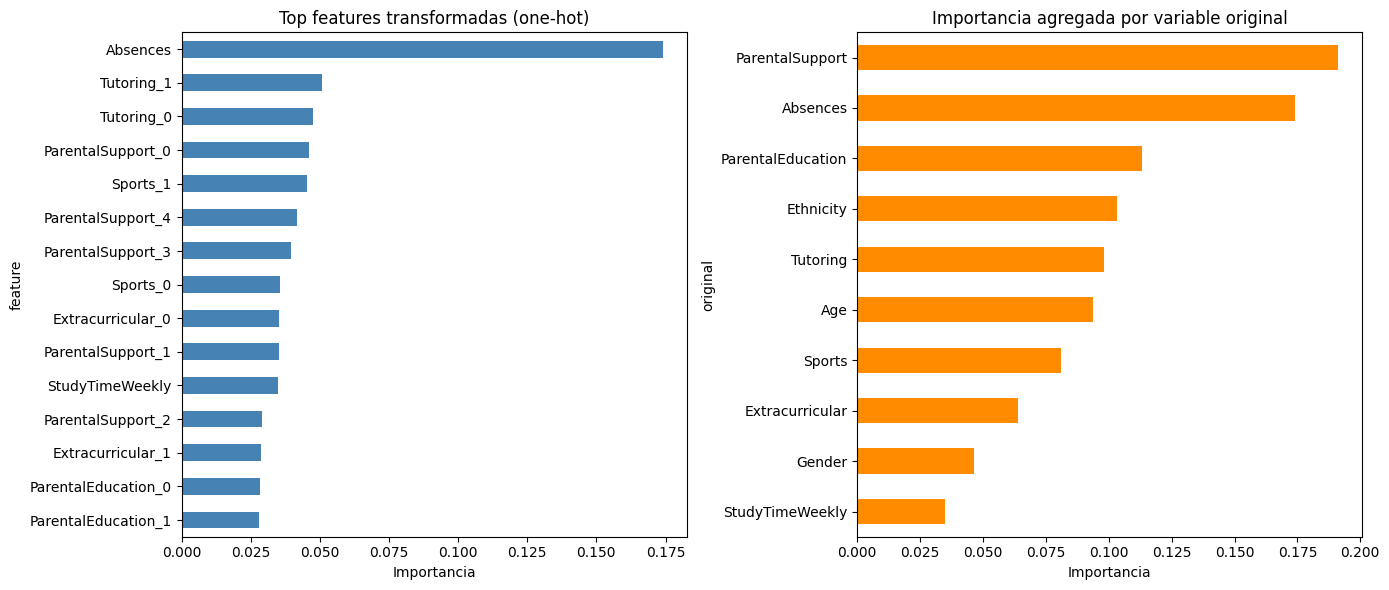

Variables más importantes (agregadas):


,original,importance
6,ParentalSupport,0.191224
0,Absences,0.173913
5,ParentalEducation,0.113185
2,Ethnicity,0.103468
9,Tutoring,0.098162
1,Age,0.093677
7,Sports,0.080866
3,Extracurricular,0.064029
4,Gender,0.046431
8,StudyTimeWeekly,0.035046


In [36]:
xgb_result = next(r for r in experiment_results if r['model'] == 'xgboost')
xgb_pipeline = xgb_result['pipeline']

preprocessor_fitted = xgb_pipeline.named_steps['preprocessor']
xgb_model = xgb_pipeline.named_steps['classifier']

cat_encoder = preprocessor_fitted.named_transformers_['cat']
transformed_feature_names = (
    list(numeric_features)
    + list(cat_encoder.get_feature_names_out(categorical_predictors))
)

importance_df = pd.DataFrame({
    'feature': transformed_feature_names,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

# Agregar importancia de columnas one-hot por variable original
def to_original_feature(name):
    if name in numeric_features:
        return name
    return name.rsplit('_', 1)[0]

importance_by_var = (
    importance_df.assign(original=importance_df['feature'].map(to_original_feature))
    .groupby('original', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

top_n = 15
importance_df.head(top_n).plot(
    kind='barh', x='feature', y='importance', legend=False, ax=ax[0], color='steelblue'
)
ax[0].set_title('Top features transformadas (one-hot)')
ax[0].set_xlabel('Importancia')
ax[0].invert_yaxis()

importance_by_var.plot(
    kind='barh', x='original', y='importance', legend=False, ax=ax[1], color='darkorange'
)
ax[1].set_title('Importancia agregada por variable original')
ax[1].set_xlabel('Importancia')
ax[1].invert_yaxis()

fig.tight_layout()
plt.show()

print('Variables más importantes (agregadas):')
display(importance_by_var)

## 5. Evaluación de Métricas

### Métrica de mayor importancia para el caso del negocio. 
El negocio quiere poder identificar la mayor cantidad de alumnos en cada GradeClass y que a su vez que cuando el modelo calsifique un alumno, este si de verdad pertenezca a esa clase.

Se busca que el modelo tenga un balance en el reconocimiento total/predicción de cada clase, es decir el recall, el cual mide que tan bueno es el modelo detectando alumnos de cada clase (GradeClass), y que su vez que también pueda ser lo más preciso posible cuando calsifica un alumno en esa clase.

Por lo tanto, la métrica más relevante en este caso es el F1 macro, que es la relación y balance entre el recall y precision, Identificando alumnos de GradeClass y acertando en la clasificación del alumno en ese GradeClass 

### Mejor Modelo
El mejor modelo luego de la exprimentación y optimización de hiperparametros con Optuna tratando de maximizar el F1 macro fue:  

**Mejor modelo:** xgboost  
**CV F1 macro:** 0.5663  
**Test accuracy:** 0.6848  
**Test precision macro:** 0.5936  
**Test recall macro:** 0.5307  
**Test F1 macro:** 0.5418  
**MLflow run id:** 73bc0aff23f342688cb285aa27c6df19  
**Hiperparámetros:** `{'n_estimators': 135, 'max_depth': 3, 'learning_rate': 0.10908534722750755, 'subsample': 0.9045389085798277, 'colsample_bytree': 0.8911431246960645}`

### Vaiables que más afectan el modelo:
1. ParentalSupport
2. Absences
3. ParentalEducation

### ¿Vale la pena usar el modelo en la institución?

En su estado actual, el mejor modelo (XGBoost) no es suficiente para tomar decisiones de forma autónoma, pero sí puede usarse como herramienta de apoyo si las alertas son revisadas por un expertos, como algún docente o equipo de orientación.

Con recall aprox. de 53% se deja pasar casi la mitad de los estudiantes de una clase. Con precision ~59% cerca de 4 de cada 10 alerta en esa clase serían incorrectas. Eso implica riesgo de intervenir con quien no lo necesita y de no alcanzar a quien sí.

**Nota**
- Estos valores son promedios macro (cada GradeClass pesa igual). El desempeño puede ser mejor o peor en clases específicas.
- El modelo sí aporta valor exploratorio: prioriza variables como ParentalSupport, Absences y ParentalEducation, alineadas con el análisis bivariado del EDA.